In [3]:
import os,re
import sys
import math
from copy import copy

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from venn import venn

import scanpy as sc
import anndata

import scanpy.external as sce
import gseapy
from scpy import scfun


mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
sc.settings.set_figure_params(facecolor=(0, 0, 0, 0), dpi=50, dpi_save=600)

sns.set_style({'axes.grid': False})

import warnings
warnings.filterwarnings('ignore')

sc.settings.figdir = f'/home/xuq44/projects/hgioa/revision2/figures'


/home/xuq44/miniconda3/envs/scpy/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### get data R

In [6]:
os.environ["R_HOME"] = "/home/xuq44/scratch/miniconda3/envs/r/lib/R" 
import rpy2
from rpy2.robjects import r


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [5]:
%%R

## Save data
library(Seurat)
library(DropletUtils)

seurat <- readRDS("/home/xuq44/projects/hgioa/revision2/data/scIBD.gex_matrix.rds")
seurat@assays$RNA@counts[1:5,1:5]

write10xCounts(x = seurat@assays$RNA@counts, path = '/home/xuq44/projects/hgioa/revision2/data/ibd/counts')
write.table(seurat@meta.data, "/home/xuq44/projects/hgioa/revision2/data/ibd/metadata.csv", quote=FALSE, sep='\t')



R[write to console]: Attaching SeuratObject

R[write to console]: Error in library(DropletUtils) : 
  there is no package called ‘DropletUtils’




Error in library(DropletUtils) : 
  there is no package called ‘DropletUtils’


### save data py

In [3]:
adata = sc.read_10x_mtx("/home/xuq44/projects/hgioa/revision2/data/ibd/counts")
metadata = pd.read_csv("/home/xuq44/projects/hgioa/revision2/data/ibd/metadata.csv", sep='\t')
adata.obs = metadata
adata.obsm['X_umap'] = adata.obs[['gUMAP_1', 'gUMAP_2']].to_numpy()




KeyboardInterrupt



In [17]:
adata

AnnData object with n_obs × n_vars = 1138625 × 16105
    obs: 'sample', 'subject', 'study', 'nUMI', 'nGene', 'rp_pct', 'mt_pct', 'minor_cluster', 'major_cluster', 'UMAP_1', 'UMAP_2', 'TSNE_1', 'TSNE_2', 'gUMAP_1', 'gUMAP_2', 'gTSNE_1', 'gTSNE_2', 'stage', 'tissue', 'tissue.sub', 'disease'
    var: 'gene_ids'
    uns: 'minor_cluster_colors', 'major_cluster_colors', 'stage_colors', 'tissue_colors', 'tissue.sub_colors', 'disease_colors'
    obsm: 'X_umap'

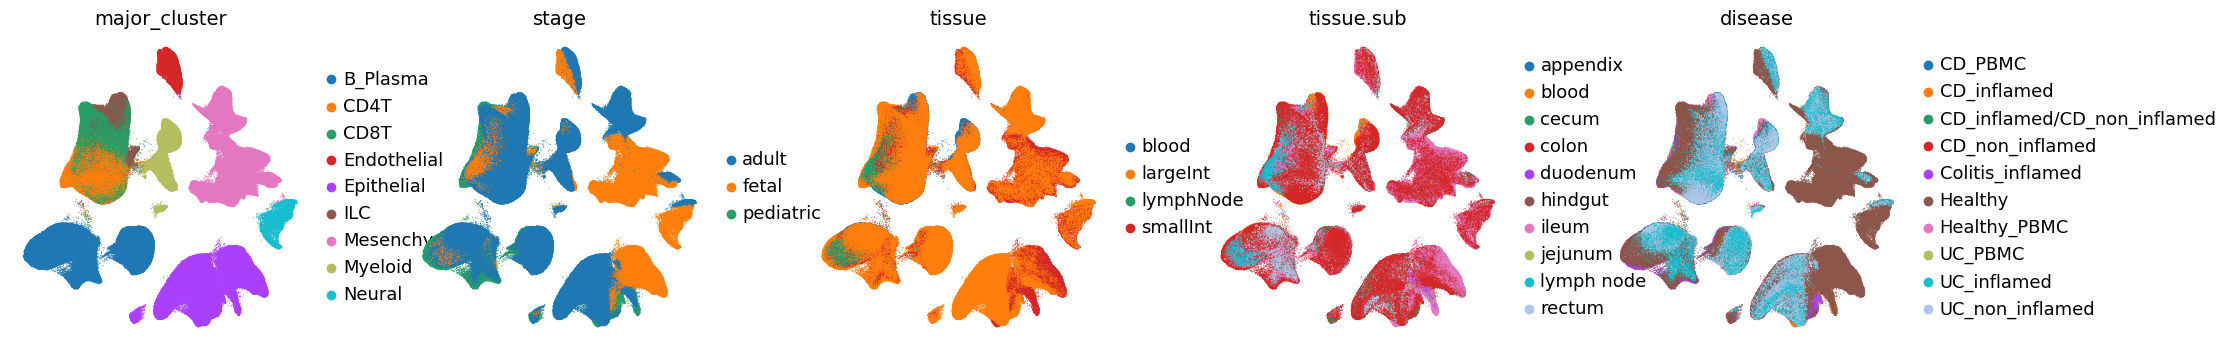

In [21]:
sc.pl.umap(adata, color=['major_cluster','stage', 'tissue', 'tissue.sub','disease'], 
           ncols=5, frameon=False, size=2)


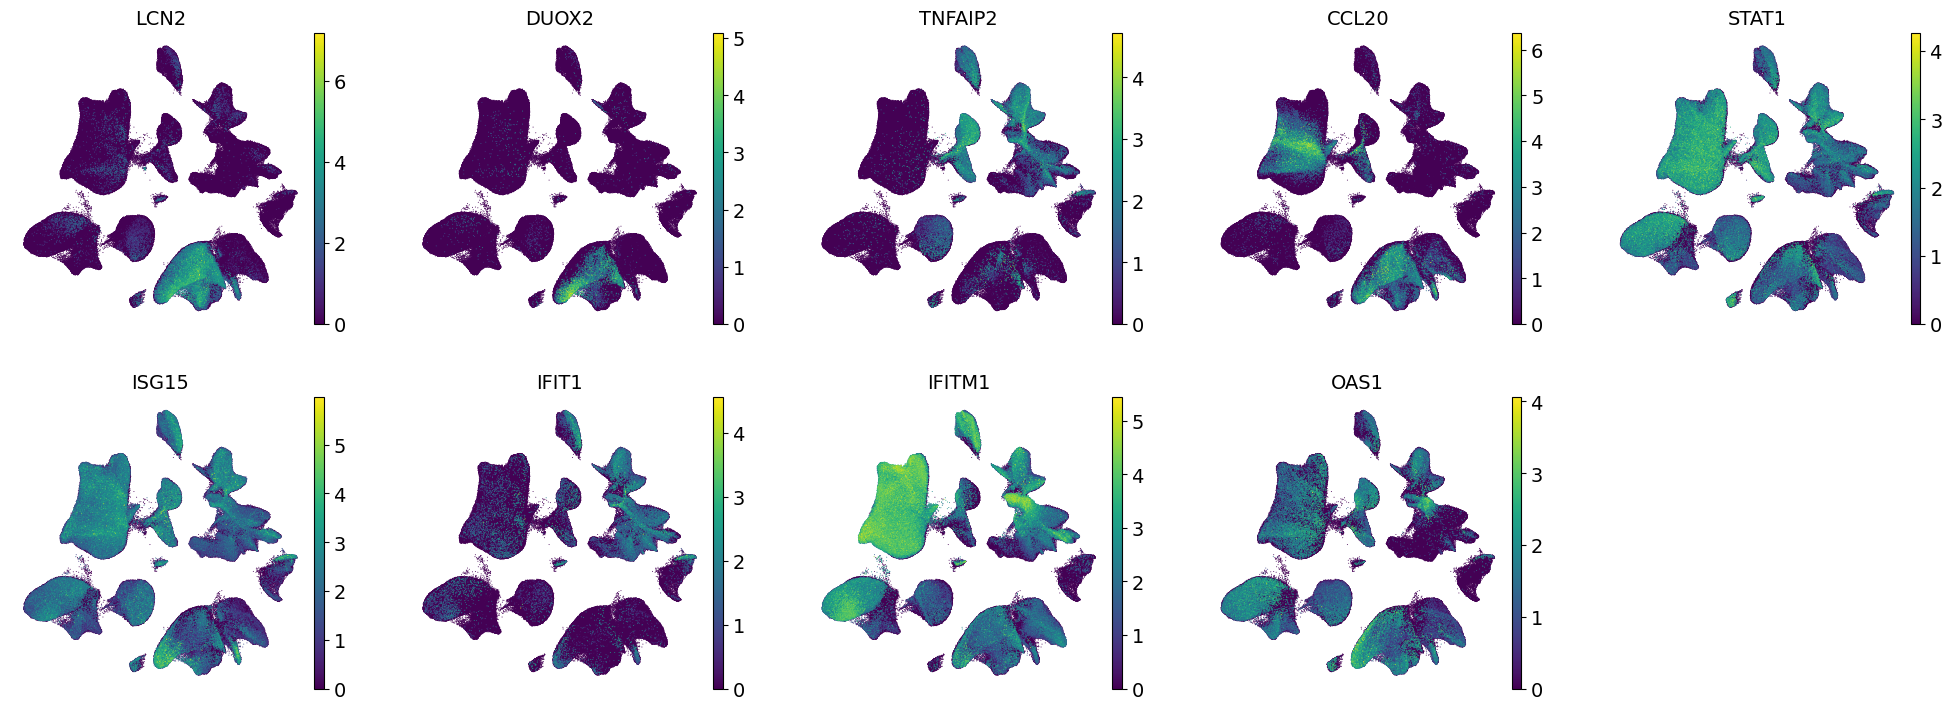

In [5]:
sc.pl.umap(adata, color=['LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1',"ISG15","IFIT1","IFITM1","OAS1"], 
           ncols=5, frameon=False, size=2)


In [8]:
adata_epi = adata[adata.obs.major_cluster=='Epithelial']

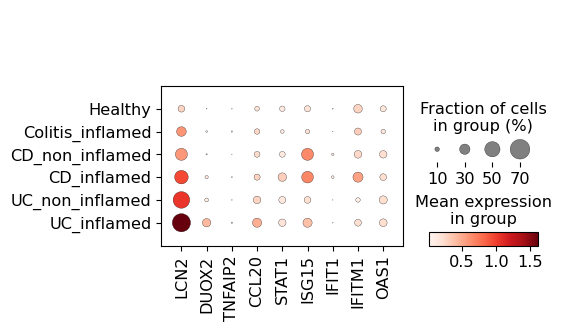

In [67]:
sc.pl.dotplot(adata_epi, ['LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1',"ISG15","IFIT1","IFITM1","OAS1",],
             groupby='disease',
             categories_order=['Healthy', 'Colitis_inflamed', 
                               'CD_non_inflamed', 'CD_inflamed', 
                               'UC_non_inflamed', 'UC_inflamed'])

In [9]:
use_samples = adata_epi.obs['sample'].value_counts()[adata_epi.obs['sample'].value_counts()>100].index.tolist()
adata_epi = adata_epi[adata_epi.obs['sample'].isin(use_samples)]
adata_epi = adata_epi[adata_epi.obs.disease.isin(['Healthy', 'Colitis_inflamed', 'CD_inflamed', 'UC_inflamed'])]
sam2dis = adata_epi.obs[['sample','disease']].set_index('sample').to_dict()['disease']

bulk_exp = scfun.get_bulk_exp(adata_epi, 'sample')


In [29]:
aaa = bulk_exp.T[['LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1', 
                  "ISG15", "CXCL11", "IFI44", "OAS2", "OAS3"]]
aaa = aaa.astype('float')
aaa['disease'] = aaa.index.map(sam2dis)
aaa = pd.melt(aaa, id_vars='disease')

aaa.disease = aaa.disease.map({'Healthy':'Healthy','Colitis_inflamed':'Colitis', 
                                  'CD_inflamed':"Crohn's disease", 
                                  'UC_inflamed':'Ulcerative colitis'})



In [141]:
%%R -i aaa -w 20 -h 15 -u cm
library(ggplot2)
library(ggpubr)
library("ggsci")
library(ggrepel)

theme_set(
  theme_bw() +
    theme(legend.position = "right")
  )

aaa$disease = factor(aaa$disease, levels = c('Healthy', 'Colitis', 'Crohn\'s disease', 'Ulcerative colitis'))
aaa$variable = factor(aaa$variable, levels = c('LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1', 
                  "ISG15", "CXCL11", "IFI44", "OAS2", "OAS3"))

my_comparisons <- list(c("Healthy", "Colitis"),
                       c("Healthy", "Crohn's disease"),
                       c("Healthy", "Ulcerative colitis"))


p <- ggplot(aaa, aes(x=disease, y=value)) + 
            geom_boxplot(aes(fill=disease),outlier.size=0.5) + scale_fill_npg()+
            scale_x_discrete(guide = guide_axis(angle = 90)) +
            facet_wrap(~variable, scale="free", ncol=5)+ 
            stat_compare_means(comparisons=my_comparisons, label = "p.signif")+
            scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
            labs(x = "Disease", y="Mean expression")

pdf("/home/xuq44/projects/hgioa/revision2/figures/ibd_gene_exp.pdf", width=6, height=5)
print(p)
dev.off()



png 
  2 


In [30]:
aaa.disease.value_counts()

Healthy               1350
Ulcerative colitis     360
Crohn's disease         90
Colitis                 90
Name: disease, dtype: int64

In [16]:
allupgenes={}
alldowngenes={}
coef_cutoff = 0.2

project_dir="/home/xuq44/projects/hgioa/data/revision"
data_dir = f'{project_dir}/results/cytokines/sc2heoca_res/'
sub_samples6 = ["IHBDECO082_006_ctr_4_5", "IHBDECO082_004_viral", "IHBDECO082_005_inflammation"]

de_genes4 = pd.read_csv(f'{data_dir}/{sub_samples6[1]}/{sub_samples6[1]}_degenes.txt', 
            index_col=0, sep='\t')

de_genes5 = pd.read_csv(f'{data_dir}/{sub_samples6[2]}/{sub_samples6[2]}_degenes.txt', 
            index_col=0, sep='\t')

allupgenes['Viral'] = set(de_genes4[(de_genes4.coef>coef_cutoff)].index.tolist())
allupgenes['Infla.'] = set(de_genes5[(de_genes5.coef>coef_cutoff)].index.tolist())
alldowngenes['all'] = set(de_genes4[(de_genes4.coef<-coef_cutoff)&(de_genes5.coef<-coef_cutoff)].index.tolist())


In [17]:
merged_degenes = pd.merge(de_genes4, de_genes5, left_index=True, right_index=True, how='outer')
# merged_degenes = merged_degenes[((merged_degenes.coef_x>0.2) & (merged_degenes.padj_x<0.01))|
#                                ((merged_degenes.coef_y>0.2) & (merged_degenes.padj_y<0.01))]
# merged_degenes = merged_degenes[(merged_degenes.coef_x>0)|(merged_degenes.coef_y>0)]

merged_degenes['condition']=None
merged_degenes.loc[merged_degenes.coef_x>0.2, 'condition'] = 'Viral'
merged_degenes.loc[merged_degenes.coef_y>0.2, 'condition'] = 'Infla.'
merged_degenes.loc[(merged_degenes.coef_x>0.2)&(merged_degenes.coef_y>0.2), 'condition'] = 'Overlap'

merged_degenes.loc[(merged_degenes.coef_x<-0.2)&(merged_degenes.coef_y<-0.2), 'condition'] = 'HEOCA'


In [38]:
bulk_exp = bulk_exp.astype('float')

In [92]:
merged_degenes_with_ibd = pd.merge(merged_degenes, bulk_exp, left_index=True, right_index=True)
gene2condition = merged_degenes_with_ibd['condition'].T.to_dict()

merged_degenes_with_ibd = merged_degenes_with_ibd.T.iloc[9:,]


In [117]:
mean_res = merged_degenes_with_ibd
mean_res['disease'] = merged_degenes_with_ibd.index.map(sam2dis)

mean_res.disease = mean_res.disease.map({'Healthy':'Healthy','Colitis_inflamed':'Colitis', 
                                  'CD_inflamed':"Crohn's disease", 
                                  'UC_inflamed':'Ulcerative colitis'})

aa = mean_res.groupby('disease').mean().T
aa['condition'] = aa.index.map(gene2condition)
aa = pd.melt(aa, id_vars='condition')
aa.head()

,condition,disease,value
0,None,Colitis,0.002556
1,None,Colitis,0.000963
2,None,Colitis,0.154949
3,None,Colitis,0.001963
4,None,Colitis,0.000698


In [152]:
gene2condition2 = {}
for i in gene2condition:
    if gene2condition[i]==None:
        gene2condition2[i]='nan'
    else:
        gene2condition2[i]=gene2condition[i]

In [160]:
mean_res = merged_degenes_with_ibd.T
mean_res['condition'] = mean_res.index.map(gene2condition2)
mean_res = mean_res.groupby('condition').mean().T
mean_res['disease'] = merged_degenes_with_ibd.index.map(sam2dis)
mean_res.disease = mean_res.disease.map({'Healthy':'Healthy','Colitis_inflamed':'Colitis', 
                                  'CD_inflamed':"Crohn's disease", 
                                  'UC_inflamed':'Ulcerative colitis'})

mean_res = pd.melt(mean_res, id_vars='disease')

mean_res.head()


,disease,condition,value
0,Healthy,HEOCA,0.539479
1,Healthy,HEOCA,0.610779
2,Healthy,HEOCA,0.550498
3,Healthy,HEOCA,0.713175
4,Healthy,HEOCA,0.727973


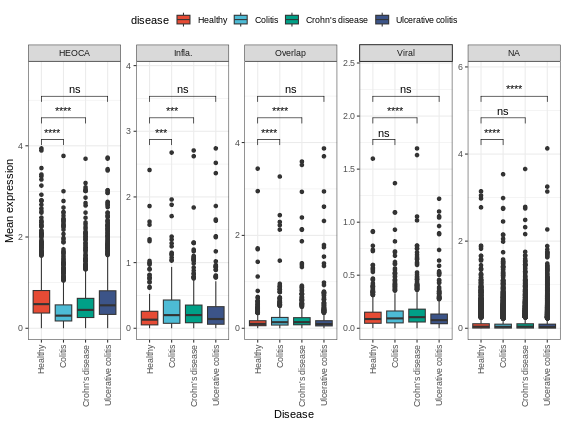

In [108]:
%%R -i aa -w 20 -h 15 -u cm

aa$disease = factor(aa$disease, levels = c('Healthy', 'Colitis', 'Crohn\'s disease', 'Ulcerative colitis'))
# aaa$variable = factor(aaa$variable, levels = c('LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1', 
#                   "ISG15", "CXCL11", "IFI44", "OAS2", "OAS3"))

# my_comparisons <- list(c("Healthy", "Colitis"),
#                        c("Healthy", "Crohn's disease"),
#                        c("Healthy", "Ulcerative colitis"))


p <- ggplot(aa, aes(x=disease, y=value)) + 
            geom_boxplot(aes(fill=disease)) + scale_fill_npg()+
            scale_x_discrete(guide = guide_axis(angle = 90)) +
            facet_wrap(~condition, scale="free", ncol=5)+ 
            stat_compare_means(comparisons=my_comparisons, label = "p.signif")+
            scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
            labs(x = "Disease", y="Mean expression")

pdf("/home/xuq44/projects/hgioa/revision2/figures/ibd_gene_exp.pdf")
print(p)
# dev.off()



In [148]:
mean_res.condition = mean_res.condition.fillna('tt')
mean_res.condition.value_counts()

HEOCA      189
Infla.     189
Overlap    189
Viral      189
Name: condition, dtype: int64

In [ ]:
%%R -i mean_res -w 20 -h 15 -u cm

mean_res$disease = factor(mean_res$disease, levels = c('Healthy', 'Colitis', 'Crohn\'s disease', 'Ulcerative colitis'))
mean_res$condition = factor(mean_res$condition, levels = c('Infla.', 'Viral', 'Overlap', 'HEOCA', 'nan'))
# aaa$variable = factor(aaa$variable, levels = c('LCN2', 'DUOX2', 'TNFAIP2', 'CCL20', 'STAT1', 
#                   "ISG15", "CXCL11", "IFI44", "OAS2", "OAS3"))

my_comparisons <- list(c("Healthy", "Colitis"),
                       c("Healthy", "Crohn's disease"),
                       c("Healthy", "Ulcerative colitis"))


p <- ggplot(mean_res, aes(x=disease, y=value)) + 
            geom_boxplot(aes(fill=disease),outlier.size=0.5) + scale_fill_npg()+
            scale_x_discrete(guide = guide_axis(angle = 90)) +
            facet_wrap(~condition, scale="free", ncol=3)+ 
            stat_compare_means(comparisons=my_comparisons, label = "p.signif")+
            scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))+
            labs(x = "Disease", y="Mean expression")

pdf("/home/xuq44/projects/hgioa/revision2/figures/ibd_allgene_exp.pdf", width=7, height=5)
print(p)
dev.off()



png 
  2 
